# 001〜005 実験結果の分析

001 (DQN without Replay), 002 (DQN with Replay), 003 (Double DQN), 004 (Dueling Network), 005 (Prioritized ER) の
`results/run001.json` 〜 `run010.json` を読み込み、
`episode_at_10_consecutive_success` の分布をヒストグラムで表示する。

**注意**: `episode_at_10_consecutive_success` が `null`（10連続成功未達）の場合は **1000** に置き換えて集計する。

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

# 日本語ラベルを表示するためにフォントを指定（DejaVu Sans は日本語非対応のため警告が出る）
plt.rcParams["font.sans-serif"] = ["MS Gothic", "Yu Gothic", "Meiryo", "sans-serif"]
plt.rcParams["axes.unicode_minus"] = False  # マイナス記号が文字化けしないように

# experiments フォルダを基準（このノートブックが experiments/ にある想定）
BASE = Path(__file__).parent if "__file__" in dir() else Path(".")
if not (BASE / "001_dqn_without_experience_replay").exists():
    BASE = Path("experiments")  # リポジトリルートから実行時

EXPERIMENTS = {
    "001 (DQN, Replayなし)": BASE / "001_dqn_without_experience_replay" / "results",
    "002 (DQN, Replayあり)": BASE / "002_dqn_with_experience_replay" / "results",
    "003 (Double DQN)": BASE / "003_double_dqn" / "results",
    "004 (Dueling Network)": BASE / "004_dueling_network" / "results",
    "005 (PER)": BASE / "005_prioritized_experience_replay" / "results",
}
NULL_REPLACEMENT = 1000  # null のときの代表値

In [2]:
def load_episode_at_success(results_dir: Path, null_replacement: int = 1000) -> list[int]:
    """results_dir 内の run*.json を読み、episode_at_10_consecutive_success のリストを返す。null は null_replacement に置換。"""
    values = []
    for p in sorted(results_dir.glob("run*.json")):
        with open(p, encoding="utf-8") as f:
            data = json.load(f)
        v = data.get("episode_at_10_consecutive_success")
        values.append(null_replacement if v is None else v)
    return values


data_for_hist = {}
for label, results_dir in EXPERIMENTS.items():
    if results_dir.exists():
        data_for_hist[label] = load_episode_at_success(results_dir, NULL_REPLACEMENT)
    else:
        data_for_hist[label] = []

for label, vals in data_for_hist.items():
    print(f"{label}: n={len(vals)}, values={vals}")

001 (DQN, Replayなし): n=10, values=[230, 198, 263, 212, 1000, 152, 193, 370, 247, 170]
002 (DQN, Replayあり): n=10, values=[106, 160, 145, 167, 101, 95, 416, 147, 115, 126]
003 (Double DQN): n=10, values=[197, 251, 255, 167, 177, 130, 140, 121, 163, 208]
004 (Dueling Network): n=10, values=[242, 196, 73, 91, 89, 333, 111, 83, 110, 211]
005 (PER): n=10, values=[253, 177, 97, 1000, 110, 164, 160, 117, 165, 200]


C:\Users\yumiy\AppData\Local\Temp\ipykernel_22408\2107120606.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax1.boxplot(data_list, labels=labels_list, patch_artist=True, showmeans=True)


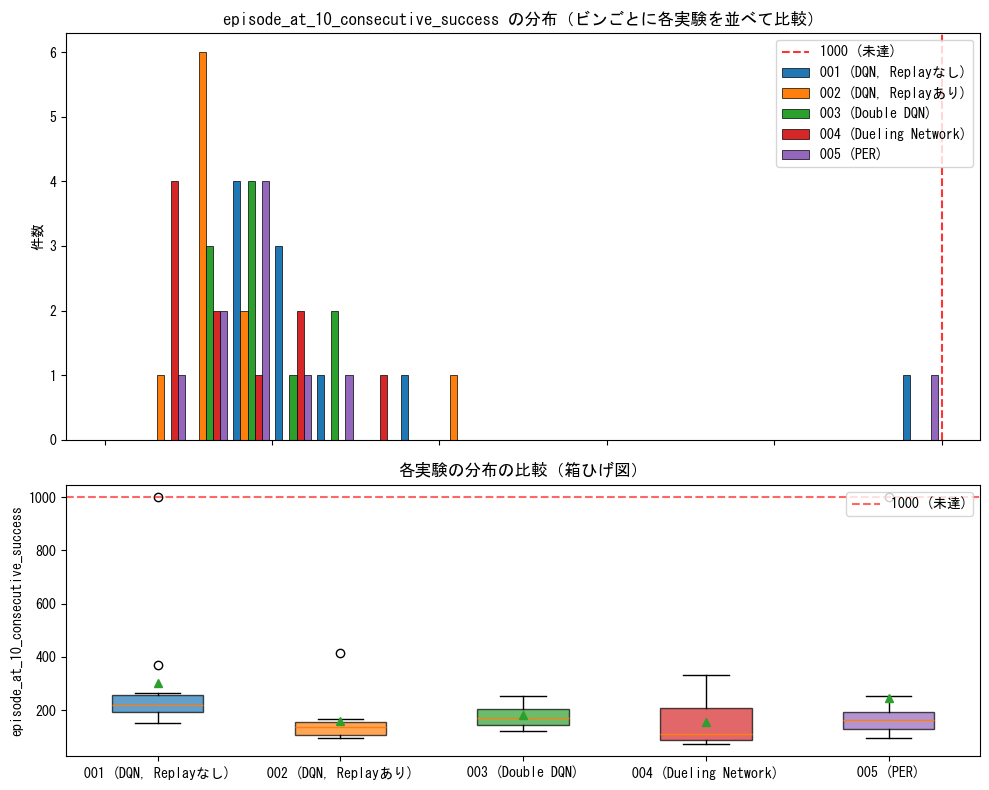

In [3]:
bins = np.linspace(0, 1000, 21)
bin_width = bins[1] - bins[0]
bin_centers = (bins[:-1] + bins[1:]) / 2
n_exp = len(data_for_hist)
# 1ビン内に n_exp 本の棒を並べるための幅とオフセット
bar_width = bin_width / max(n_exp, 1) * 0.85
offsets = np.linspace(-(n_exp - 1) / 2 * bar_width, (n_exp - 1) / 2 * bar_width, n_exp)
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd"]

fig, axes = plt.subplots(2, 1, figsize=(10, 8), gridspec_kw={"height_ratios": [1.5, 1]})

# 上: グループ化したヒストグラム（ビンごとに各実験の棒を横並び）
ax0 = axes[0]
for (label, values), offset, color in zip(data_for_hist.items(), offsets, colors[:n_exp]):
    counts, _ = np.histogram(values, bins=bins)
    ax0.bar(bin_centers + offset, counts, width=bar_width, label=label, color=color, edgecolor="black", linewidth=0.5)
ax0.axvline(NULL_REPLACEMENT, color="red", linestyle="--", alpha=0.8, label="1000 (未達)")
ax0.set_ylabel("件数")
ax0.set_title("episode_at_10_consecutive_success の分布（ビンごとに各実験を並べて比較）")
ax0.legend(loc="upper right")
ax0.set_xticklabels([])

# 下: 箱ひげ図（中央値・四分位・ばらつきを並べて比較）
ax1 = axes[1]
data_list = [data_for_hist[k] for k in data_for_hist if data_for_hist[k]]
labels_list = [k for k in data_for_hist if data_for_hist[k]]
bp = ax1.boxplot(data_list, labels=labels_list, patch_artist=True, showmeans=True)
for patch, color in zip(bp["boxes"], colors[: len(labels_list)]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax1.axhline(NULL_REPLACEMENT, color="red", linestyle="--", alpha=0.6, label="1000 (未達)")
ax1.set_ylabel("episode_at_10_consecutive_success")
ax1.set_title("各実験の分布の比較（箱ひげ図）")
ax1.legend(loc="upper right")

plt.tight_layout()
plt.show()